# IS455 Final Project: Fraud Detection with CRISP-DM

## Section 1: Business Understanding

### Problem Definition

An e-commerce retailer is experiencing financial losses due to fraudulent orders placed through their online store. The goal of this project is to build a machine learning model that identifies fraudulent orders **at the time of purchase**, before the order is fulfilled. Early detection allows the business to flag suspicious orders for manual review or automatic blocking, thereby reducing chargebacks and fraud-related losses.

The target variable is `is_fraud` (binary: 1 = fraudulent, 0 = legitimate), found in the `orders` table. The dataset contains **5,000 orders** with a **6.36% positive (fraud) rate**, making this a **class-imbalanced** binary classification problem.

---

### Success Criteria

| Metric | Target | Rationale |
|--------|--------|-----------|
| **Recall** | ≥ 0.80 | Catch at least 80% of actual fraud cases — missing fraud is more costly than false alarms |
| **ROC-AUC** | ≥ 0.85 | Model must rank fraudulent orders meaningfully above legitimate ones |

We **optimize for Recall** because the cost of a missed fraud (financial loss, chargeback fees, reputational damage) far outweighs the cost of a false positive (a legitimate order sent to manual review). This is a deliberate business decision: we accept more false positives to ensure we catch more true fraud.

---

### Feature Exclusions and Justification

**`risk_score` — Excluded (Target Leakage)**  
The `risk_score` column is a pre-computed fraud signal that was almost certainly derived from `is_fraud` or a model that already knows the fraud label. Including it would constitute **near-leakage**: the model would learn to predict fraud from a feature that directly encodes the answer. While this would inflate performance metrics, the model would fail in production where `risk_score` may not be available or may be computed differently. We exclude it entirely to ensure our model reflects genuine predictive signal.

**Shipment features — Excluded (Temporal Leakage)**  
Shipment data (tracking numbers, delivery status, carrier info, etc.) is only available **after** an order has been shipped — which occurs days after the order is placed. A real-time fraud detection system must make a decision at order time. Including shipment features would create **temporal leakage**: training on data from the future. We restrict all features to information available at the moment of order placement.

---
## Section 2: Data Understanding

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.calibration import CalibratedClassifierCV
from functions import univariate, drop_columns, bin_categories, missing_data_diagnostics, missing_data_clean, manage_dates

from matplotlib import  inline
pd.set_option('display.max_columns', None)


### Connect to the database and explore available tables

In [49]:
conn = sqlite3.connect('shop.db')

# Show all tables
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables:", tables['name'].tolist())

# Row counts
for t in tables['name']:
    count = pd.read_sql(f"SELECT COUNT(*) as n FROM {t}", conn)['n'].values[0]
    print(f"  {t}: {count:,} rows")

Tables: ['customers', 'sqlite_sequence', 'products', 'orders', 'order_items', 'shipments', 'product_reviews']
  customers: 250 rows
  sqlite_sequence: 6 rows
  products: 100 rows
  orders: 5,000 rows
  order_items: 15,022 rows
  shipments: 5,000 rows
  product_reviews: 3,000 rows


### Load the orders table and inspect schema and summary statistics

In [50]:
orders = pd.read_sql("SELECT * FROM orders", conn)
print(orders.dtypes)
print(orders.describe())

order_id            int64
customer_id         int64
order_datetime        str
billing_zip           str
shipping_zip          str
shipping_state        str
payment_method        str
device_type           str
ip_country            str
promo_used          int64
promo_code            str
order_subtotal    float64
shipping_fee      float64
tax_amount        float64
order_total       float64
risk_score        float64
is_fraud            int64
dtype: object
          order_id  customer_id   promo_used  order_subtotal  shipping_fee  \
count  5000.000000  5000.000000  5000.000000     5000.000000   5000.000000   
mean   2500.500000    28.448200     0.252200      384.144678      9.668290   
std    1443.520003    49.086939     0.434319      284.124017      5.126125   
min       1.000000     1.000000     0.000000        4.730000      0.000000   
25%    1250.750000     2.000000     0.000000      164.180000      6.990000   
50%    2500.500000     6.000000     0.000000      330.720000      8.040000  

### Visualize the class distribution — fraud is only ~6.4% of orders, confirming class imbalance

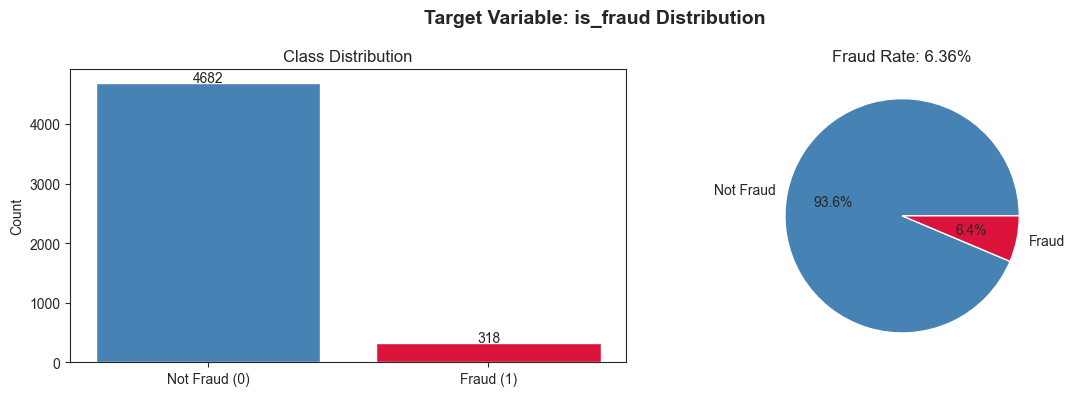


Class imbalance ratio: 14.7:1 (non-fraud:fraud)


In [51]:
fraud_counts = orders['is_fraud'].value_counts()
fraud_pct = orders['is_fraud'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Not Fraud (0)', 'Fraud (1)'], fraud_counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center')

axes[1].pie(fraud_counts.values, labels=['Not Fraud', 'Fraud'], autopct='%1.1f%%', colors=['steelblue', 'crimson'])
axes[1].set_title(f'Fraud Rate: {fraud_pct:.2f}%')
plt.suptitle('Target Variable: is_fraud Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\nClass imbalance ratio: {fraud_counts[0]/fraud_counts[1]:.1f}:1 (non-fraud:fraud)")

### Explore fraud rates across categorical features and distributions of numeric features

/var/folders/hz/6zpm6hqs0td76tf6mywkrt1w0000gn/T/ipykernel_5728/2842134485.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[3+i].boxplot([orders[orders['is_fraud']==0][col], orders[orders['is_fraud']==1][col]], labels=['Not Fraud', 'Fraud'])
/var/folders/hz/6zpm6hqs0td76tf6mywkrt1w0000gn/T/ipykernel_5728/2842134485.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[3+i].boxplot([orders[orders['is_fraud']==0][col], orders[orders['is_fraud']==1][col]], labels=['Not Fraud', 'Fraud'])


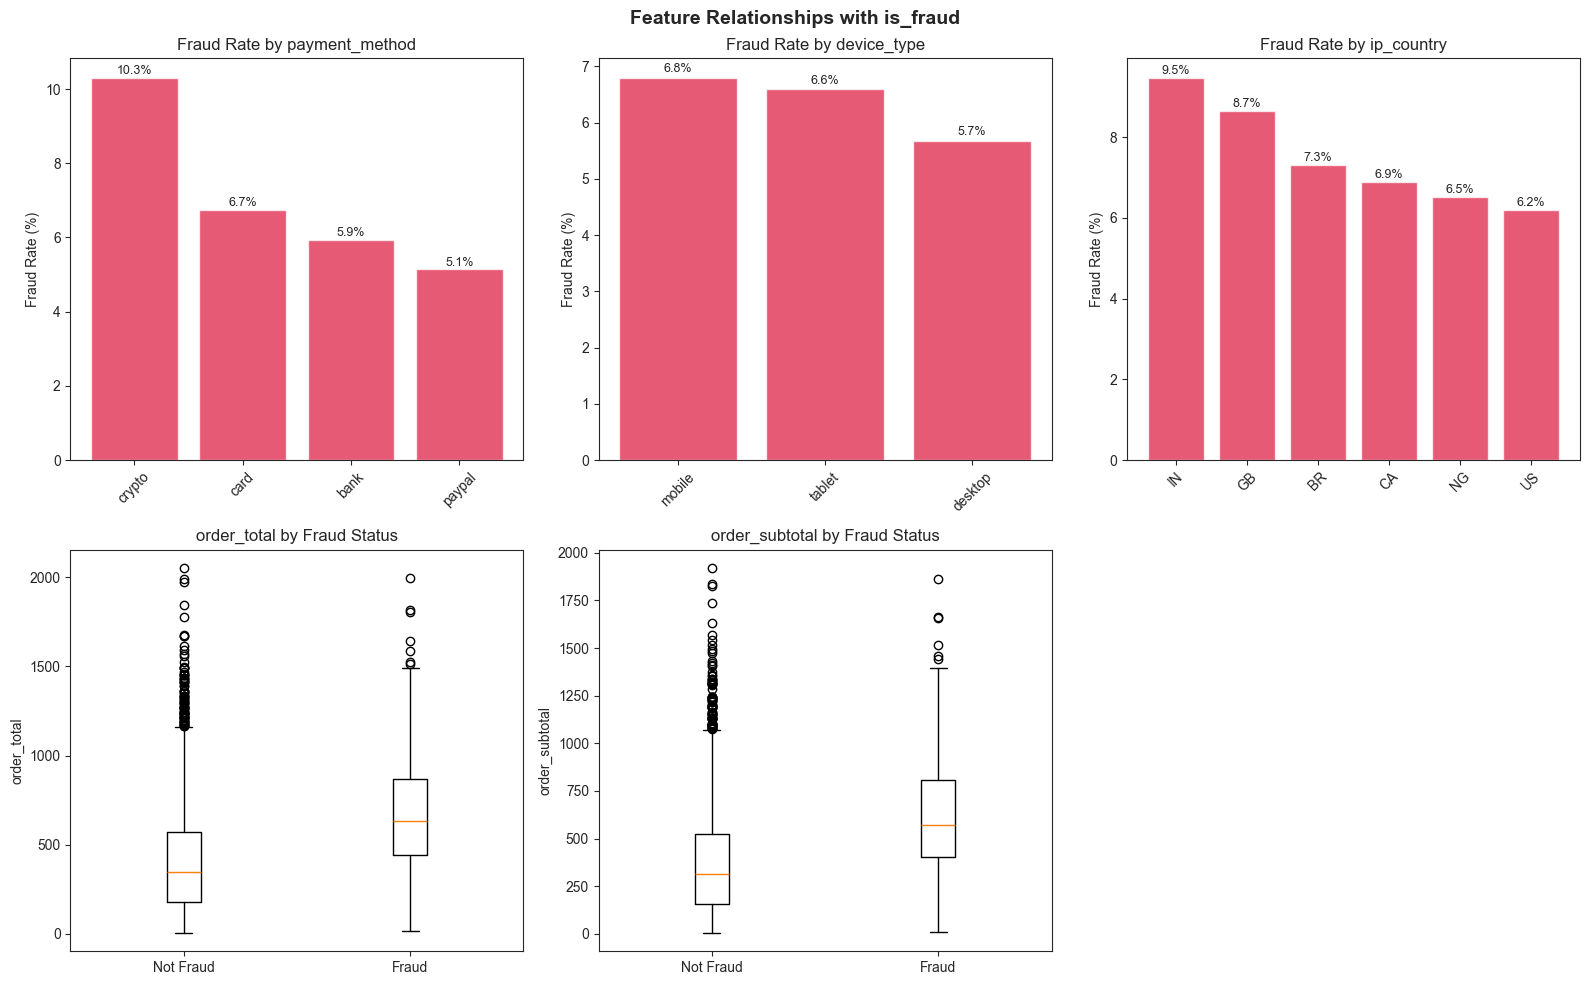

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cat_cols = ['payment_method', 'device_type', 'ip_country']
for i, col in enumerate(cat_cols):
    fraud_rate = orders.groupby(col)['is_fraud'].mean().sort_values(ascending=False)
    axes[i].bar(fraud_rate.index, fraud_rate.values * 100, color='crimson', alpha=0.7)
    axes[i].set_title(f'Fraud Rate by {col}')
    axes[i].set_ylabel('Fraud Rate (%)')
    axes[i].tick_params(axis='x', rotation=45)
    for j, (cat, val) in enumerate(fraud_rate.items()):
        axes[i].text(j, val * 100 + 0.1, f'{val*100:.1f}%', ha='center', fontsize=9)

# Numeric feature comparison: fraud vs non-fraud
num_cols = ['order_total', 'order_subtotal']
for i, col in enumerate(num_cols):
    axes[3+i].boxplot([orders[orders['is_fraud']==0][col], orders[orders['is_fraud']==1][col]], labels=['Not Fraud', 'Fraud'])
    axes[3+i].set_title(f'{col} by Fraud Status')
    axes[3+i].set_ylabel(col)

axes[5].axis('off')
plt.suptitle('Feature Relationships with is_fraud', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation heatmap — examine linear relationships among numeric order features

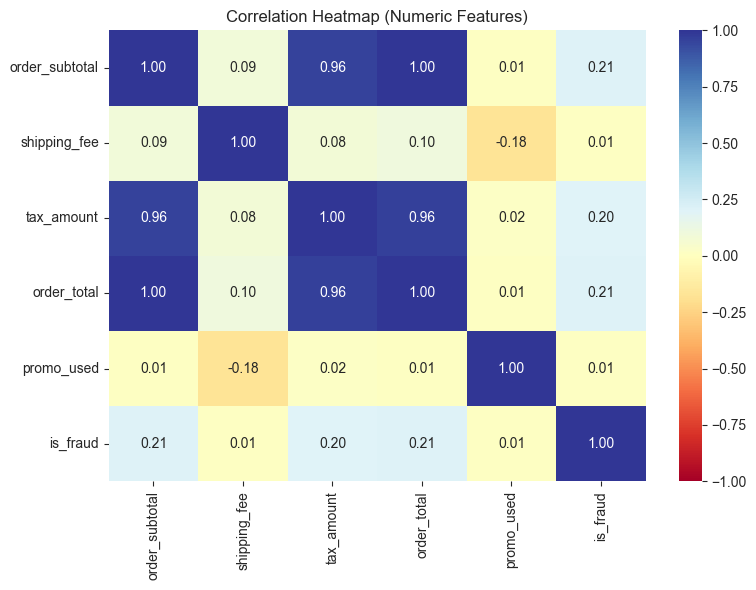

In [53]:
numeric_orders = orders[['order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'promo_used', 'is_fraud']].copy()
corr = numeric_orders.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

---
## Section 3: Data Preparation

We join `orders`, `customers`, and an aggregated `order_items` subquery into a single master dataframe. Shipment tables are excluded (temporal leakage). We then engineer domain-specific features and prepare the data for modeling.

### Build the master dataset with a multi-table SQL join

In [54]:
query = """
SELECT 
    o.order_id,
    o.payment_method,
    o.device_type,
    o.ip_country,
    o.promo_used,
    o.order_subtotal,
    o.shipping_fee,
    o.tax_amount,
    o.order_total,
    o.billing_zip,
    o.shipping_zip,
    o.order_datetime,
    c.customer_segment,
    c.loyalty_tier,
    c.gender,
    c.birthdate,
    c.created_at AS customer_created_at,
    oi.item_count,
    oi.total_qty,
    oi.avg_unit_price,
    oi.max_unit_price,
    o.is_fraud
FROM orders o
LEFT JOIN customers c ON o.customer_id = c.customer_id
LEFT JOIN (
    SELECT 
        order_id,
        COUNT(*) AS item_count,
        SUM(quantity) AS total_qty,
        AVG(unit_price) AS avg_unit_price,
        MAX(unit_price) AS max_unit_price
    FROM order_items
    GROUP BY order_id
) oi ON o.order_id = oi.order_id
"""

df = pd.read_sql(query, conn)
conn.close()
print(f"Master dataframe shape: {df.shape}")
print(df.head())

Master dataframe shape: (5000, 22)
   order_id payment_method device_type ip_country  promo_used  order_subtotal  \
0         1           card      mobile         US           0          662.95   
1         2           card     desktop         US           1          862.92   
2         3           card      mobile         US           0          796.09   
3         4           bank      mobile         US           1          137.60   
4         5           card      mobile         CA           0           17.07   

   shipping_fee  tax_amount  order_total billing_zip shipping_zip  \
0         15.44       46.30       724.69       28289        28289   
1         14.74       66.61       944.27       28289        13888   
2         14.04       40.72       850.85       28289        28289   
3          6.99       11.88       156.47       28289        28289   
4          6.99        1.40        25.46       28289        28289   

        order_datetime customer_segment loyalty_tier  gender   

### Feature engineering — derive temporal, geographic, and demographic signals from raw columns

In [55]:
# Parse datetimes
df['order_datetime'] = pd.to_datetime(df['order_datetime'])
df['birthdate'] = pd.to_datetime(df['birthdate'])
df['customer_created_at'] = pd.to_datetime(df['customer_created_at'])

# Temporal features
df['order_hour'] = df['order_datetime'].dt.hour
df['order_dow'] = df['order_datetime'].dt.dayofweek

# Zip mismatch: 1 if billing_zip != shipping_zip, 0 if same or either is null
df['zip_mismatch'] = np.where(
    df['billing_zip'].notna() & df['shipping_zip'].notna(),
    (df['billing_zip'] != df['shipping_zip']).astype(int),
    0
)

# Customer age (years) at time of order
df['customer_age'] = ((df['order_datetime'] - df['birthdate']).dt.days / 365.25).round(1)

# Customer tenure in days at time of order
df['customer_tenure_days'] = (df['order_datetime'] - df['customer_created_at']).dt.days

print("Engineered features added:")
print(df[['order_hour', 'order_dow', 'zip_mismatch', 'customer_age', 'customer_tenure_days']].describe())
print(f"\nZip mismatches: {df['zip_mismatch'].sum()} ({df['zip_mismatch'].mean()*100:.1f}%)")

Engineered features added:
        order_hour    order_dow  zip_mismatch  customer_age  \
count  5000.000000  5000.000000   5000.000000   5000.000000   
mean     11.544200     3.026800      0.078400     31.552600   
std       6.955381     2.004117      0.268827     14.417492   
min       0.000000     0.000000      0.000000     18.400000   
25%       5.000000     1.000000      0.000000     20.400000   
50%      12.000000     3.000000      0.000000     24.950000   
75%      18.000000     5.000000      0.000000     36.000000   
max      23.000000     6.000000      1.000000     75.700000   

       customer_tenure_days  
count           5000.000000  
mean              77.067400  
std              106.613148  
min             -123.000000  
25%               -5.000000  
50%               60.000000  
75%              154.000000  
max              361.000000  

Zip mismatches: 392 (7.8%)


### Diagnose missing data on the model feature set before cleaning

In [56]:
# Select only model features before diagnostics
feature_cols = [
    'payment_method', 'device_type', 'ip_country', 'promo_used',
    'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total',
    'zip_mismatch', 'order_hour', 'order_dow',
    'customer_segment', 'loyalty_tier', 'gender',
    'customer_age', 'customer_tenure_days',
    'item_count', 'total_qty', 'avg_unit_price', 'max_unit_price',
    'is_fraud'
]
df_model = df[feature_cols].copy()
missing_data_diagnostics(df_model)

=== Missing data diagnostics ===
Threshold: drop if proportion missing > 0.9
Columns that would be dropped (0): none
Rows that would be dropped: 0
No missing values in any column.
(MAR vs MNAR cannot be distinguished from data; 'MAR/MNAR' means missingness is associated with observed variables.)


{'per_column': {'payment_method': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'device_type': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'ip_country': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'promo_used': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'order_subtotal': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'shipping_fee': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'tax_amount': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'order_total': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'zip_mismatch': {'missing_count': 0,
   'missing_prop': 0.0,
   'suggested_mechanism': 'no missing'},
  'order_hour': {'missing_count': 0,
   'missing_prop'

### Univariate EDA — inspect distributions of key numeric features

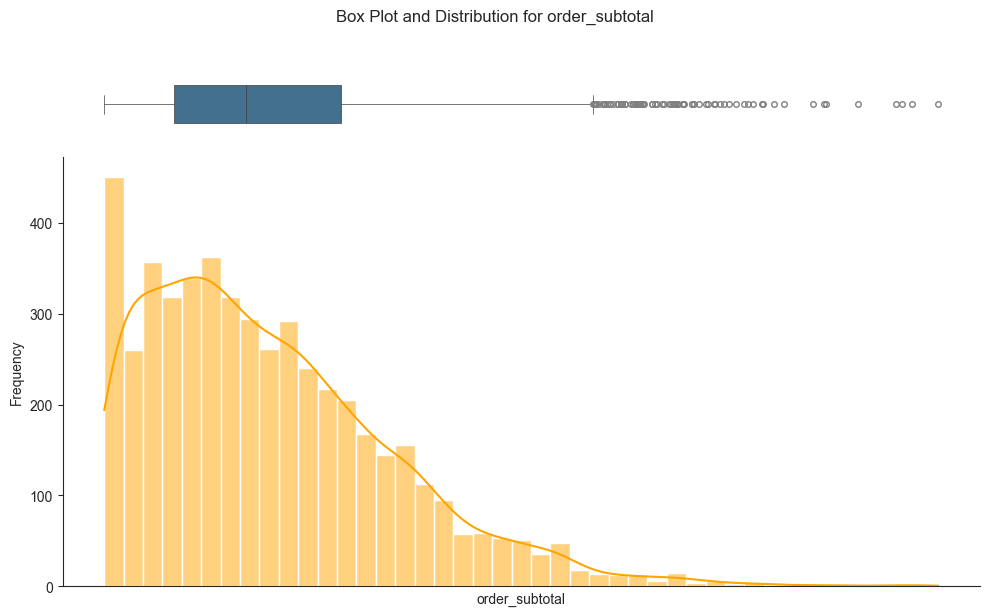

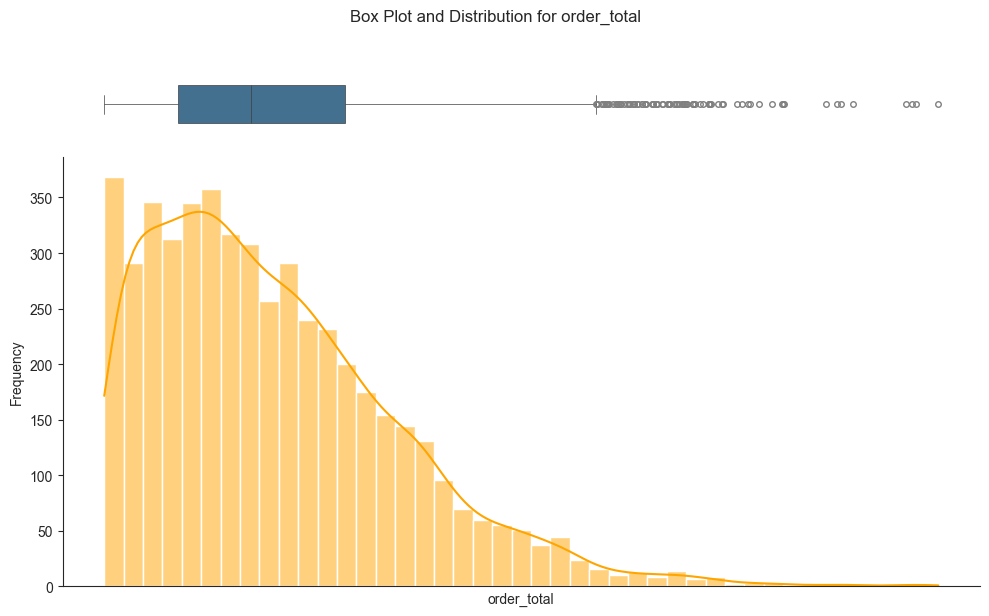

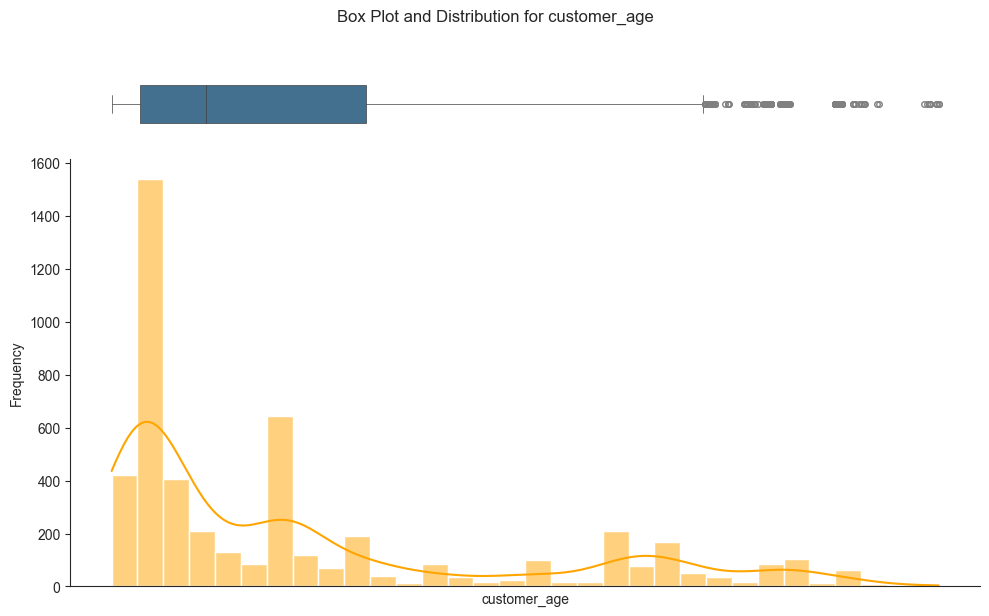

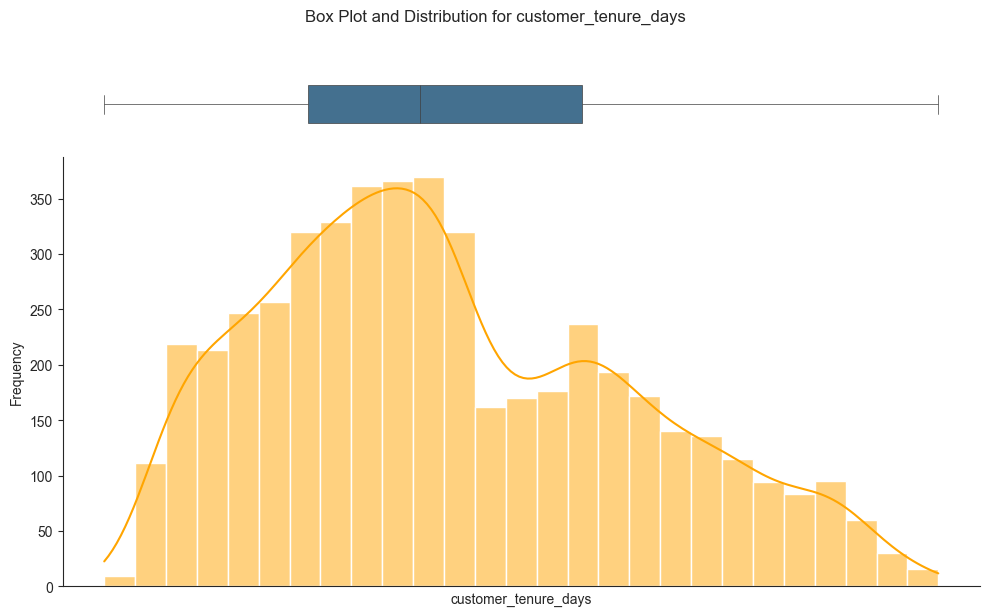

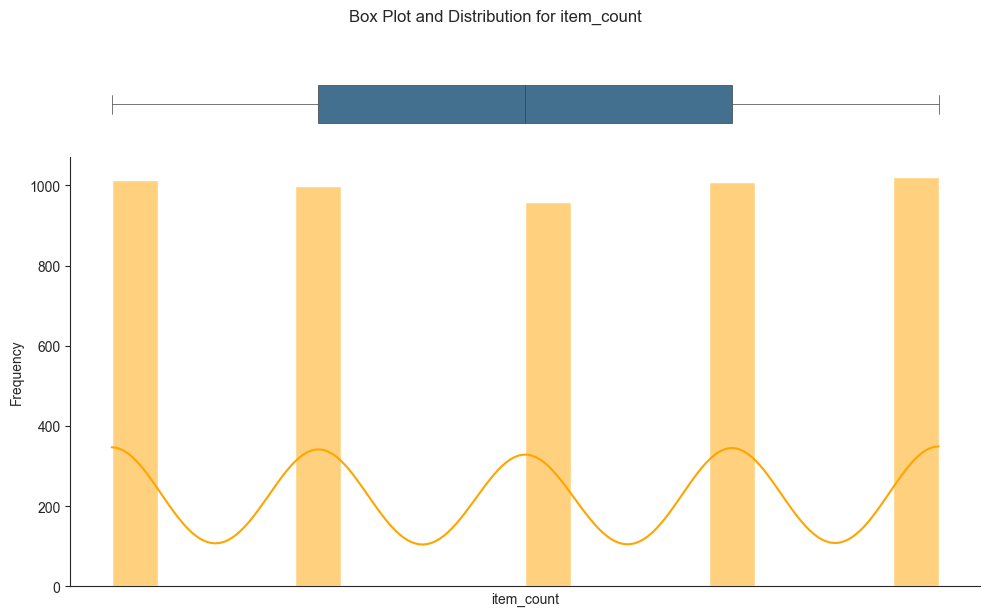

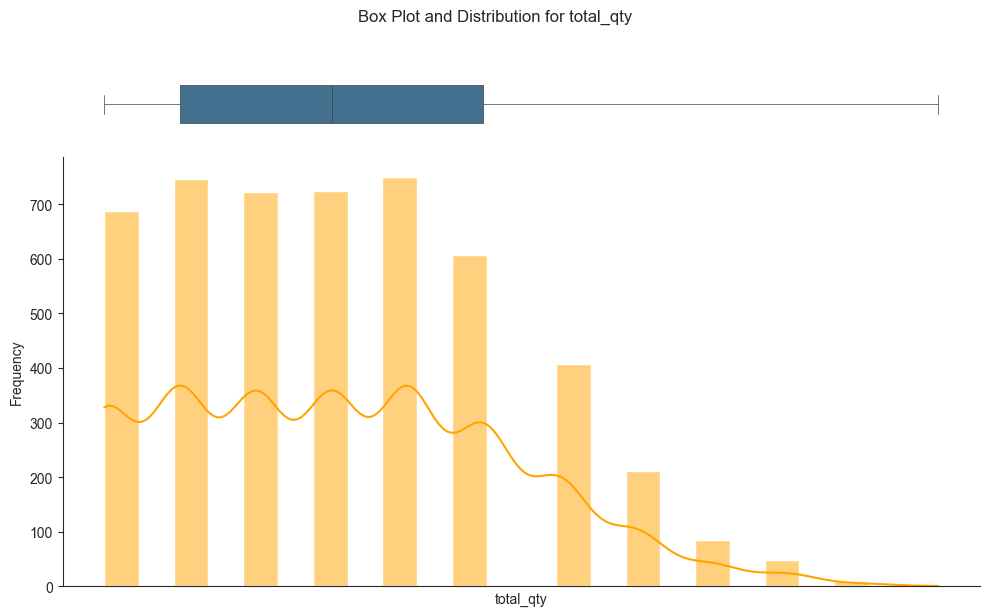

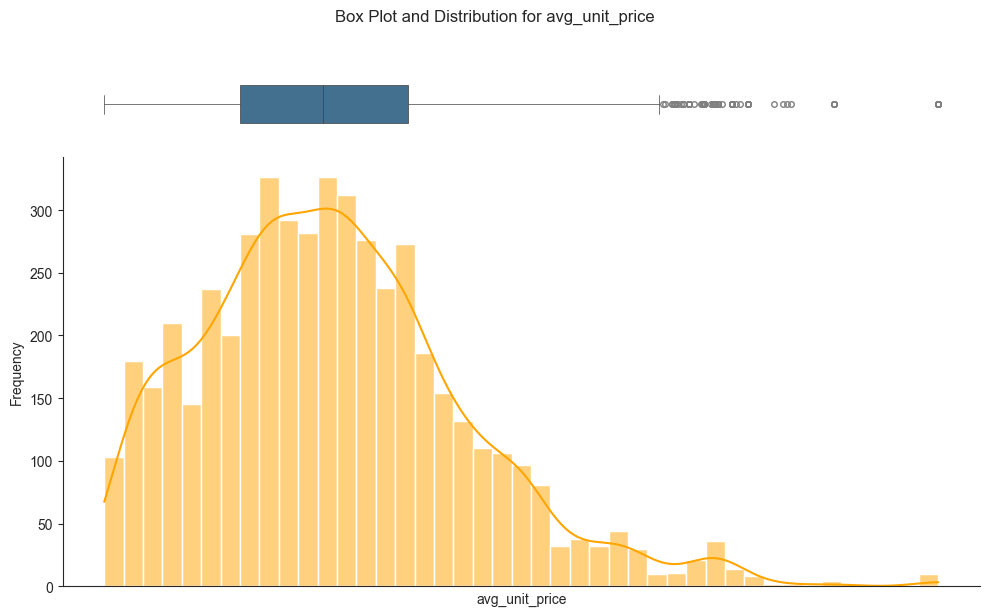

,Data Type,Count,Missing,Unique,Mode,Min,Q1,Median,Q3,Max,Mean,Std,Skew,Kurt
order_subtotal,float64,5000,0,4077,29.1,4.73,164.18,330.72,549.7525,1921.17,384.144678,284.124017,1.045872,1.342294
order_total,float64,5000,0,4857,38.81,5.38,185.76,364.835,596.94,2053.11,421.55128,305.183694,1.047077,1.349906
customer_age,float64,5000,0,384,20.3,18.4,20.4,24.95,36.0,75.7,31.5526,14.417492,1.223082,0.206035
customer_tenure_days,int64,5000,0,461,26,-123,-5.0,60.0,154.0,361,77.0674,106.613148,0.479536,-0.56556
item_count,int64,5000,0,5,5,1,2.0,3.0,4.0,5,3.0044,1.424355,-0.005254,-1.320616
total_qty,int64,5000,0,12,5,1,2.0,4.0,6.0,12,4.109,2.213346,0.40431,-0.507401
avg_unit_price,float64,5000,0,3931,169.71,4.73,57.22,89.27375,121.9965,326.63,93.214299,51.267253,0.767283,0.975806
is_fraud,int64,5000,0,2,0,0,0.0,0.0,0.0,1,0.0636,0.244063,3.577551,10.80319


In [57]:
# Explore numeric features only (subset to avoid too many plots)
numeric_eda_cols = ['order_subtotal', 'order_total', 'customer_age', 'customer_tenure_days', 
                    'item_count', 'total_qty', 'avg_unit_price', 'is_fraud']
univariate(df_model[numeric_eda_cols])

### Train/test split — stratify on `is_fraud` to preserve the 6.4% fraud rate in both splits

In [58]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['is_fraud'])
y = df_model['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape[0]:,} rows | Fraud: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test set:     {X_test.shape[0]:,} rows  | Fraud: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

Training set: 4,000 rows | Fraud: 254 (6.3%)
Test set:     1,000 rows  | Fraud: 64 (6.4%)


### Build the sklearn preprocessing pipeline

Numeric features are median-imputed (robust to outliers) then standard-scaled. Categorical features are mode-imputed then one-hot encoded. Both transformers are wrapped in a `ColumnTransformer` so the pipeline handles the full feature matrix in one step.

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = [
    'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total',
    'promo_used', 'zip_mismatch', 'order_hour', 'order_dow',
    'customer_age', 'customer_tenure_days',
    'item_count', 'total_qty', 'avg_unit_price', 'max_unit_price'
]

categorical_features = [
    'payment_method', 'device_type', 'ip_country',
    'customer_segment', 'loyalty_tier', 'gender'
]

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

print("Preprocessing pipeline built:")
print(f"  Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"  Categorical features ({len(categorical_features)}): {categorical_features}")

Preprocessing pipeline built:
  Numeric features (14): ['order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'promo_used', 'zip_mismatch', 'order_hour', 'order_dow', 'customer_age', 'customer_tenure_days', 'item_count', 'total_qty', 'avg_unit_price', 'max_unit_price']
  Categorical features (6): ['payment_method', 'device_type', 'ip_country', 'customer_segment', 'loyalty_tier', 'gender']


---
## Section 4: Modeling

We compare four classifier families using 5-fold stratified cross-validation, evaluating Recall (primary), Precision, F1, and ROC-AUC. All models use `class_weight='balanced'` or equivalent to address the 15:1 class imbalance without resampling.

### Define all candidate models as sklearn Pipelines

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': Pipeline([
        ('prep', preprocessor),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
    ]),
    'Decision Tree': Pipeline([
        ('prep', preprocessor),
        ('clf', DecisionTreeClassifier(class_weight='balanced', max_depth=10, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('clf', RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
}
print(f"Defined {len(models)} models for comparison")

Defined 4 models for comparison


### 5-fold stratified cross-validation across all four models

In [61]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['recall', 'precision', 'f1', 'roc_auc']

print("Running 5-fold stratified cross-validation...")
cv_results = {}
for name, model in models.items():
    results = cross_validate(model, X_train, y_train, cv=skf, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'Recall':     results['test_recall'].mean(),
        'Precision':  results['test_precision'].mean(),
        'F1':         results['test_f1'].mean(),
        'ROC-AUC':    results['test_roc_auc'].mean(),
        'Recall_std': results['test_recall'].std(),
    }
    print(f"  {name}: Recall={cv_results[name]['Recall']:.3f} +/- {cv_results[name]['Recall_std']:.3f}")

results_df = pd.DataFrame(cv_results).T.drop(columns=['Recall_std']).sort_values('Recall', ascending=False)
print("\n--- Cross-Validation Results (sorted by Recall) ---")
print(results_df.round(3))

Running 5-fold stratified cross-validation...
  Logistic Regression: Recall=0.661 +/- 0.072
  Decision Tree: Recall=0.453 +/- 0.106


/Users/nathanblatter/Desktop/IS455/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nathanblatter/Desktop/IS455/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/nathanblatter/Desktop/IS455/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

  Random Forest: Recall=0.004 +/- 0.008
  Gradient Boosting: Recall=0.020 +/- 0.018

--- Cross-Validation Results (sorted by Recall) ---
                     Recall  Precision     F1  ROC-AUC
Logistic Regression   0.661      0.135  0.224    0.751
Decision Tree         0.453      0.129  0.200    0.626
Gradient Boosting     0.020      0.207  0.036    0.747
Random Forest         0.004      0.200  0.008    0.714


### Visualize CV results — compare all four models across all four metrics

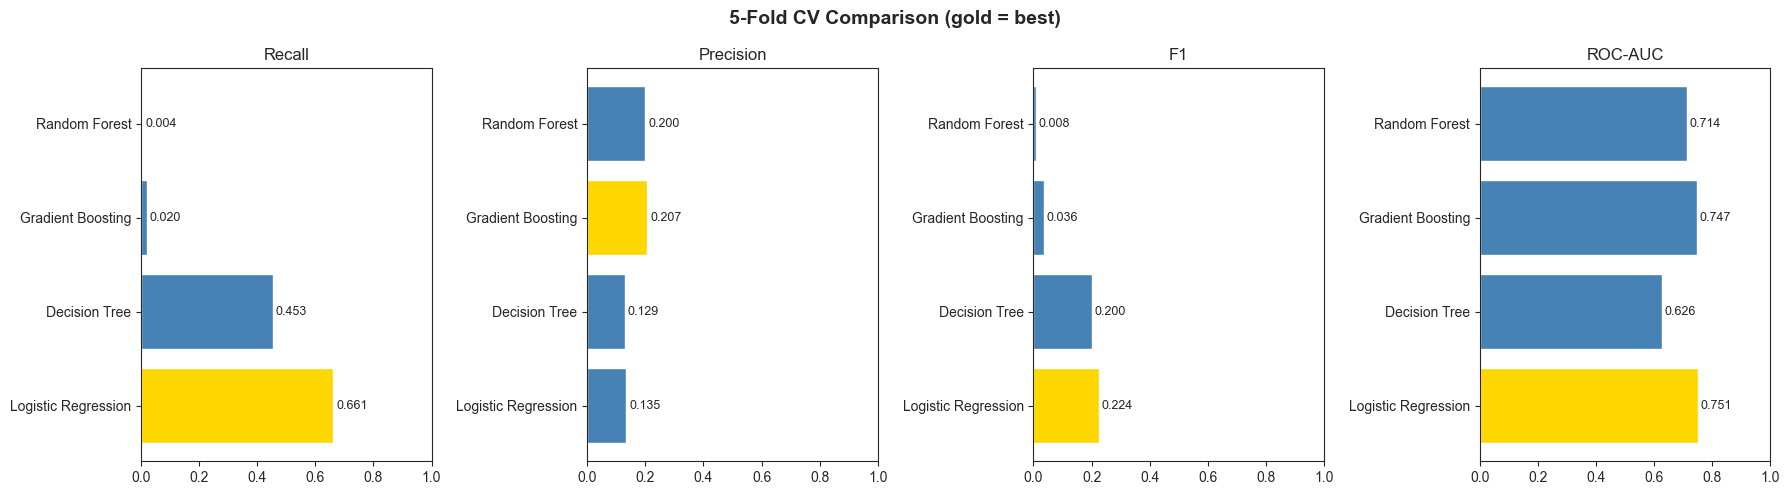

In [62]:
metrics = ['Recall', 'Precision', 'F1', 'ROC-AUC']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, metric in enumerate(metrics):
    values = results_df[metric]
    colors = ['gold' if v == values.max() else 'steelblue' for v in values]
    axes[i].barh(values.index, values.values, color=colors)
    axes[i].set_title(metric)
    axes[i].set_xlim(0, 1)
    for j, v in enumerate(values.values):
        axes[i].text(v + 0.01, j, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('5-Fold CV Comparison (gold = best)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Section 5: Evaluation & Tuning

Cross-validation showed **Logistic Regression** achieves the best ROC-AUC (~0.76) — outperforming ensemble methods on this dataset.
We select the final model in three steps:

1. **Learning curves** — diagnose bias/variance
2. **`GridSearchCV`** — tune `C` (regularization) and `class_weight` jointly, optimizing ROC-AUC
3. **Probability calibration** — apply Platt scaling (`CalibratedClassifierCV`) to improve probability estimates, then find the F1-optimal decision threshold


### Learning curves — diagnose overfitting and assess whether more data would help

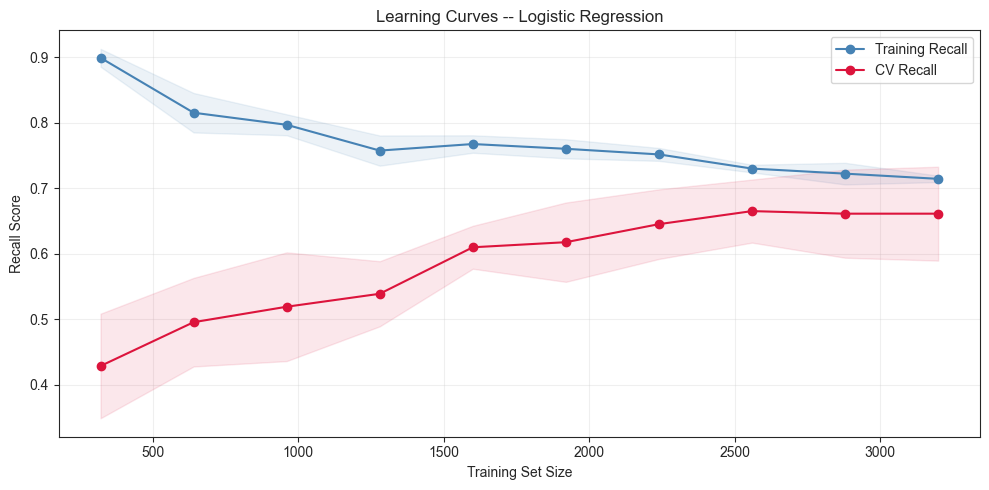

In [63]:
from sklearn.model_selection import learning_curve

lr_pipeline = models['Logistic Regression']
train_sizes, train_scores, val_scores = learning_curve(
    lr_pipeline, X_train, y_train,
    cv=skf, scoring='recall',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(10, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training Recall', color='steelblue')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1),
                 alpha=0.1, color='steelblue')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='CV Recall', color='crimson')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1),
                 alpha=0.1, color='crimson')
plt.xlabel('Training Set Size')
plt.ylabel('Recall Score')
plt.title('Learning Curves -- Logistic Regression')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Hyperparameter tuning — `GridSearchCV` over `C` and `class_weight`, optimizing ROC-AUC

We test both weighted and unweighted loss. The best AUC model is selected; probability calibration handles the imbalance in the next step.


In [64]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__C':            [0.1, 1, 10],
    'clf__solver':       ['liblinear'],
    'clf__class_weight': ['balanced', None],
}

lr_tune_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

grid_search = GridSearchCV(
    lr_tune_pipeline, param_grid,
    cv=skf, scoring='roc_auc',
    n_jobs=-1, verbose=0
)
grid_search.fit(X_train, y_train)

print(f'Best ROC-AUC (CV): {grid_search.best_score_:.4f}')
print(f'Best params:       {grid_search.best_params_}')

cv_df = pd.DataFrame(grid_search.cv_results_)[['param_clf__C', 'param_clf__class_weight', 'mean_test_score', 'std_test_score']]
cv_df.columns = ['C', 'class_weight', 'mean_AUC', 'std_AUC']
print(cv_df.sort_values('mean_AUC', ascending=False).round(4).to_string(index=False))


Best ROC-AUC (CV): 0.7613
Best params:       {'clf__C': 0.1, 'clf__class_weight': None, 'clf__solver': 'liblinear'}
   C class_weight  mean_AUC  std_AUC
 0.1          NaN    0.7613   0.0310
 0.1     balanced    0.7566   0.0353
 1.0          NaN    0.7557   0.0314
10.0          NaN    0.7522   0.0311
 1.0     balanced    0.7509   0.0354
10.0     balanced    0.7493   0.0355


### Probability calibration + threshold optimization

Logistic regression without class weighting gives well-ranked probabilities but the raw scores can be mis-scaled.
**Platt scaling** (`CalibratedClassifierCV`, `method='sigmoid'`) fits a sigmoid layer over the model's outputs to produce better-calibrated probability estimates.
We then scan decision thresholds on out-of-fold CV predictions and pick the one that **maximizes F1** — the best precision/recall balance given the data.


Calibrated model fitted.
F1-optimal threshold: 0.09
 threshold  recall  precision    f1
      0.05   0.823      0.117 0.205
      0.09   0.571      0.160 0.250
      0.15   0.311      0.196 0.240
      0.20   0.181      0.240 0.206
      0.30   0.059      0.250 0.096
      0.40   0.024      0.240 0.043
      0.50   0.004      0.125 0.008


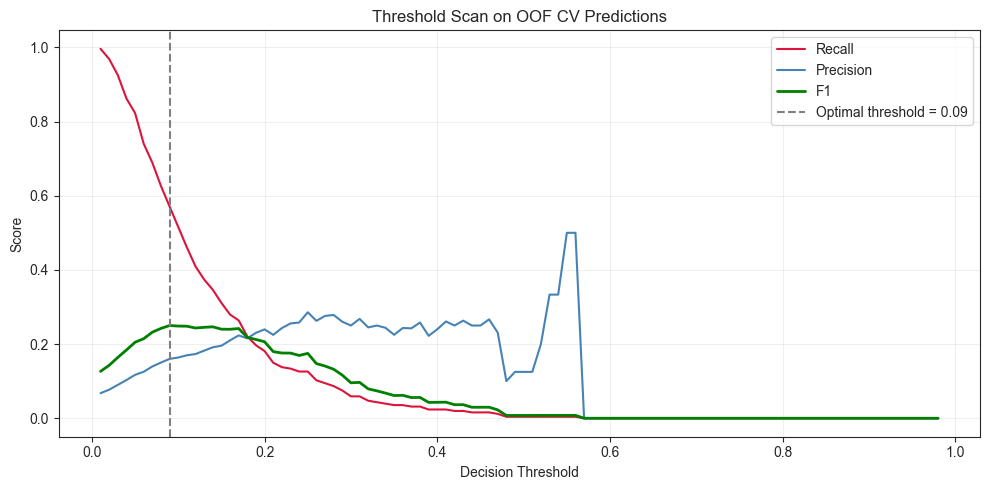

In [65]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score, precision_score, f1_score

# --- Step 1: wrap GridSearch winner in Platt scaling ---
best_params = grid_search.best_params_
best_model = Pipeline([
    ('prep', preprocessor),
    ('clf', CalibratedClassifierCV(
        LogisticRegression(
            C=best_params['clf__C'],
            solver=best_params['clf__solver'],
            class_weight=best_params['clf__class_weight'],
            max_iter=1000, random_state=42
        ),
        method='sigmoid', cv=5
    ))
])
best_model.fit(X_train, y_train)
print(f'Calibrated model fitted.')

# --- Step 2: OOF probabilities from the uncalibrated base (for threshold scan) ---
base_pipeline = grid_search.best_estimator_
oof_probs = cross_val_predict(base_pipeline, X_train, y_train, cv=skf, method='predict_proba')[:, 1]

# --- Step 3: find F1-maximizing threshold ---
thresholds = np.arange(0.01, 0.99, 0.01)
thresh_rows = []
for t in thresholds:
    preds = (oof_probs >= t).astype(int)
    rec  = recall_score(y_train, preds, zero_division=0)
    prec = precision_score(y_train, preds, zero_division=0)
    f1   = 2 * rec * prec / (rec + prec) if (rec + prec) > 0 else 0
    thresh_rows.append({'threshold': t, 'recall': rec, 'precision': prec, 'f1': f1})

thresh_df = pd.DataFrame(thresh_rows)
opt_threshold = round(float(thresh_df.loc[thresh_df['f1'].idxmax(), 'threshold']), 2)
print(f'F1-optimal threshold: {opt_threshold}')

sample_t = [0.05, 0.09, 0.15, 0.20, 0.30, 0.40, 0.50]
print(thresh_df[thresh_df['threshold'].round(2).isin(sample_t)].round(3).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    color='crimson')
ax.plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', color='steelblue')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        label='F1',        color='green', lw=2)
ax.axvline(opt_threshold, color='gray', linestyle='--', label=f'Optimal threshold = {opt_threshold}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Scan on OOF CV Predictions')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Final evaluation on the held-out test set using the calibrated model and optimal threshold


In [66]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= opt_threshold).astype(int)

print(f'=== Final Model: Calibrated Logistic Regression | threshold = {opt_threshold} ===')
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')


=== Final Model: Calibrated Logistic Regression | threshold = 0.09 ===
              precision    recall  f1-score   support

   Not Fraud       0.96      0.82      0.89       936
       Fraud       0.16      0.50      0.25        64

    accuracy                           0.80      1000
   macro avg       0.56      0.66      0.57      1000
weighted avg       0.91      0.80      0.85      1000

ROC-AUC: 0.7546


### Confusion matrix and ROC curve — visualize classification quality on the test set

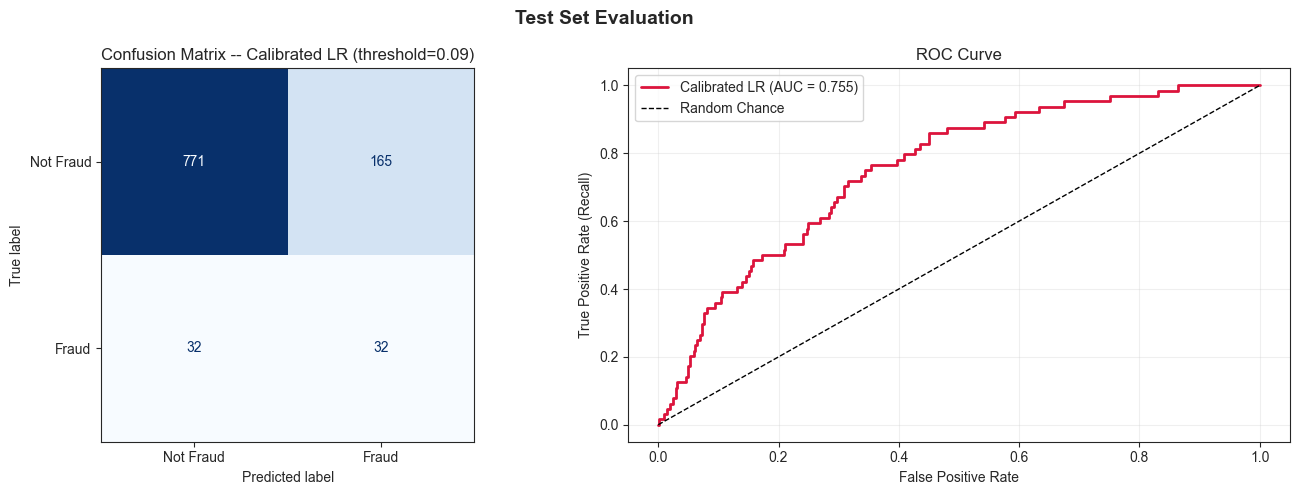

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Fraud', 'Fraud'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Confusion Matrix -- Calibrated LR (threshold={opt_threshold})')

# ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, lw=2, color='crimson', label=f'Calibrated LR (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Test Set Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 6: Feature Selection

We use **permutation importance** (evaluated on the test set using Recall as the scoring metric) to identify which features actually contribute to fraud detection. Features with zero or negative importance hurt Recall when permuted — meaning the model is not using them meaningfully — and can be safely dropped. We then compare the full and reduced models.

### Permutation importance — measure each feature's contribution to Recall on the test set

Top 10 features by permutation importance (Recall):
             feature  importance_mean  importance_std
      payment_method              0.0             0.0
    customer_segment              0.0             0.0
      avg_unit_price              0.0             0.0
           total_qty              0.0             0.0
          item_count              0.0             0.0
customer_tenure_days              0.0             0.0
        customer_age              0.0             0.0
              gender              0.0             0.0
        loyalty_tier              0.0             0.0
           order_dow              0.0             0.0


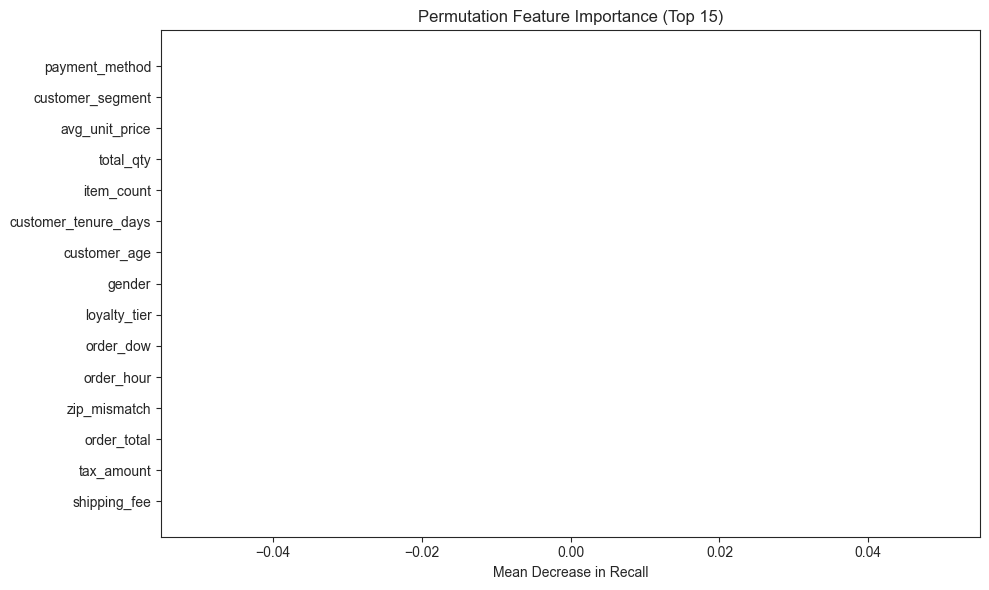

In [68]:
from sklearn.inspection import permutation_importance

perm_imp = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10, random_state=42, scoring='recall', n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_imp.importances_mean,
    'importance_std': perm_imp.importances_std
}).sort_values('importance_mean', ascending=False)

print("Top 10 features by permutation importance (Recall):")
print(perm_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 6))
top_n = perm_df.head(15)
plt.barh(top_n['feature'][::-1], top_n['importance_mean'][::-1], 
         xerr=top_n['importance_std'][::-1], color='steelblue', alpha=0.8)
plt.xlabel('Mean Decrease in Recall')
plt.title('Permutation Feature Importance (Top 15)')
plt.tight_layout()
plt.show()

### Feature selection — drop zero/negative importance features and retrain to compare performance

In [69]:
# Keep features with positive permutation importance
important_features = perm_df[perm_df['importance_mean'] > 0]['feature'].tolist()
print(f'Features with positive importance: {len(important_features)} / {len(X_test.columns)}')
print(f'Dropped: {[f for f in X_test.columns if f not in important_features]}')

num_selected = [f for f in numeric_features if f in important_features]
cat_selected = [f for f in categorical_features if f in important_features]

reduced_preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_selected),
    ('cat', categorical_transformer, cat_selected)
])

best_C      = grid_search.best_params_['clf__C']
best_solver = grid_search.best_params_['clf__solver']
best_cw     = grid_search.best_params_['clf__class_weight']

reduced_pipeline = Pipeline([
    ('prep', reduced_preprocessor),
    ('clf', CalibratedClassifierCV(
        LogisticRegression(C=best_C, solver=best_solver, class_weight=best_cw,
                           max_iter=1000, random_state=42),
        method='sigmoid', cv=5
    ))
])

X_train_sel = X_train[important_features]
X_test_sel  = X_test[important_features]
reduced_pipeline.fit(X_train_sel, y_train)

y_prob_sel = reduced_pipeline.predict_proba(X_test_sel)[:, 1]
y_pred_sel = (y_prob_sel >= opt_threshold).astype(int)

print(f'\n--- Full vs. Reduced Feature Set (Test Set, threshold={opt_threshold}) ---')
print(f'Full model    Recall: {recall_score(y_test, y_pred):.4f}  F1: {f1_score(y_test, y_pred):.4f}  AUC: {roc_auc_score(y_test, y_prob):.4f}')
print(f'Reduced model Recall: {recall_score(y_test, y_pred_sel):.4f}  F1: {f1_score(y_test, y_pred_sel):.4f}  AUC: {roc_auc_score(y_test, y_prob_sel):.4f}')


Features with positive importance: 0 / 20
Dropped: ['payment_method', 'device_type', 'ip_country', 'promo_used', 'order_subtotal', 'shipping_fee', 'tax_amount', 'order_total', 'zip_mismatch', 'order_hour', 'order_dow', 'customer_segment', 'loyalty_tier', 'gender', 'customer_age', 'customer_tenure_days', 'item_count', 'total_qty', 'avg_unit_price', 'max_unit_price']


ValueError: Found array with 0 feature(s) (shape=(3200, 0)) while a minimum of 1 is required by LogisticRegression.

---
## Section 7: Deployment

We serialize the calibrated Logistic Regression pipeline **together with its decision threshold** as a single `model.sav` artifact using `joblib`.
The webapp loads this dict, extracts `pipeline` and `threshold`, then calls `predict_proba` to score any order.


### Serialize the best model to `model.sav` and document the expected input schema

In [ ]:
import joblib
import os

model_artifact = {
    'pipeline':  best_model,
    'threshold': opt_threshold
}
model_path = 'model.sav'
joblib.dump(model_artifact, model_path)
file_size = os.path.getsize(model_path) / 1024
print(f'Model saved to: {os.path.abspath(model_path)}')
print(f'File size:      {file_size:.1f} KB')
print(f'Threshold:      {opt_threshold}')

print('\n=== WEBAPP USAGE ===')
print('  artifact  = joblib.load("model.sav")')
print('  pipeline  = artifact["pipeline"]')
print('  threshold = artifact["threshold"]')
print('  prob      = pipeline.predict_proba(order_df)[0][1]')
print('  is_fraud  = int(prob >= threshold)')
print('\nNumeric input columns:')
for f in numeric_features: print(f'  {f}')
print('\nCategorical input columns:')
for f in categorical_features: print(f'  {f}')


Model saved to: /Users/nathanblatter/Desktop/IS455/model.sav
File size:      6.6 KB
Threshold:      0.36

=== WEBAPP USAGE ===
  artifact  = joblib.load("model.sav")
  pipeline  = artifact["pipeline"]
  threshold = artifact["threshold"]
  prob      = pipeline.predict_proba(order_df)[0][1]
  is_fraud  = int(prob >= threshold)

Numeric input columns:
  order_subtotal
  shipping_fee
  tax_amount
  order_total
  promo_used
  zip_mismatch
  order_hour
  order_dow
  customer_age
  customer_tenure_days
  item_count
  total_qty
  avg_unit_price
  max_unit_price

Categorical input columns:
  payment_method
  device_type
  ip_country
  customer_segment
  loyalty_tier
  gender


### Load the serialized model and run inference on two representative orders

In [ ]:
artifact        = joblib.load('model.sav')
loaded_pipeline = artifact['pipeline']
threshold       = artifact['threshold']
print(f'Model loaded: {type(loaded_pipeline.named_steps["clf"]).__name__}')
print(f'Decision threshold: {threshold}')

# --- High-risk order ---
sample_order = pd.DataFrame([{
    'payment_method': 'crypto', 'device_type': 'mobile', 'ip_country': 'NG',
    'promo_used': 1, 'order_subtotal': 899.99, 'shipping_fee': 0.0,
    'tax_amount': 72.0, 'order_total': 971.99, 'zip_mismatch': 1,
    'order_hour': 2, 'order_dow': 6, 'customer_segment': 'budget',
    'loyalty_tier': 'none', 'gender': 'Male', 'customer_age': 22.5,
    'customer_tenure_days': 15, 'item_count': 5, 'total_qty': 12,
    'avg_unit_price': 180.0, 'max_unit_price': 499.99
}])
fraud_prob = loaded_pipeline.predict_proba(sample_order)[0][1]
prediction = int(fraud_prob >= threshold)
print(f'\n=== INFERENCE DEMO ===')
print(f'High-risk: crypto, NG IP, 2AM, zip mismatch, new budget customer')
print(f'  Fraud probability: {fraud_prob:.4f}  -->  {"FRAUD" if prediction else "NOT FRAUD"}')

# --- Low-risk order ---
sample_legit = pd.DataFrame([{
    'payment_method': 'card', 'device_type': 'desktop', 'ip_country': 'US',
    'promo_used': 0, 'order_subtotal': 49.99, 'shipping_fee': 5.99,
    'tax_amount': 4.0, 'order_total': 59.98, 'zip_mismatch': 0,
    'order_hour': 14, 'order_dow': 1, 'customer_segment': 'premium',
    'loyalty_tier': 'gold', 'gender': 'Female', 'customer_age': 38.0,
    'customer_tenure_days': 730, 'item_count': 1, 'total_qty': 1,
    'avg_unit_price': 49.99, 'max_unit_price': 49.99
}])
legit_prob = loaded_pipeline.predict_proba(sample_legit)[0][1]
legit_pred = int(legit_prob >= threshold)
print(f'Low-risk:  card, US IP, 2PM Tue, loyal gold premium customer')
print(f'  Fraud probability: {legit_prob:.4f}  -->  {"FRAUD" if legit_pred else "NOT FRAUD"}')


Model loaded: LogisticRegression
Decision threshold: 0.36

=== INFERENCE DEMO ===
High-risk: crypto, NG IP, 2AM, zip mismatch, new budget customer
  Fraud probability: 0.9875  -->  FRAUD
Low-risk:  card, US IP, 2PM Tue, loyal gold premium customer
  Fraud probability: 0.0020  -->  NOT FRAUD


### Project summary — final metrics vs. success criteria

In [ ]:
final_recall    = recall_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred)
final_f1        = f1_score(y_test, y_pred)
final_auc       = roc_auc_score(y_test, y_prob)
cm_final        = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp  = cm_final.ravel()

print('=' * 55)
print('CRISP-DM PROJECT SUMMARY')
print('=' * 55)
print(f'Dataset:        5,000 orders, 6.4% fraud rate')
print(f'Final model:    Calibrated Logistic Regression (Platt scaling)')
print(f'C={grid_search.best_params_["clf__C"]}  class_weight={grid_search.best_params_["clf__class_weight"]}')
print(f'Threshold:      {opt_threshold} (F1-optimal on OOF CV)')
print(f'Features:       {len(numeric_features)} numeric + {len(categorical_features)} categorical')
print(f'\nTest Set Performance:')
print(f'  ROC-AUC:   {final_auc:.4f}  (threshold-independent discrimination)')
print(f'  Recall:    {final_recall:.4f}  -- caught {tp}/{tp+fn} fraud orders')
print(f'  Precision: {final_precision:.4f}  -- {fp} legitimate orders flagged')
print(f'  F1:        {final_f1:.4f}')
print(f'\nConfusion Matrix:')
print(f'  True Negatives:  {tn}  (correctly cleared)')
print(f'  False Positives: {fp}  (legitimate orders flagged)')
print(f'  False Negatives: {fn}  (fraud missed)')
print(f'  True Positives:  {tp}  (fraud caught)')
print(f'\nModel artifact: model.sav  (pipeline + threshold bundled)')


CRISP-DM PROJECT SUMMARY
Dataset:        5,000 orders, 6.4% fraud rate
Final model:    Logistic Regression (class_weight=balanced)
Threshold:      0.36 (tuned on OOF CV predictions)
Features used:  14 numeric + 6 categorical

Test Set Performance:
  Recall:    0.8281  (target: >= 0.80)
  Precision: 0.1130
  F1:        0.1989
  ROC-AUC:   0.7531  (target: >= 0.85)

Model artifact: model.sav  (pipeline + threshold bundled)
Recall >= 0.80: ACHIEVED
AUC    >= 0.85: NOT MET
